In [11]:
import pandas as pd
#Data Cleaning 
df = pd.read_csv("data.csv")
#Getting rid of useless data
df = df.drop(columns=['id', 'Unnamed: 32'])
#Enumerating the diagnosis for future calculations
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})


In [12]:
import numpy as np
#Separating data into traning and testing sets

X = df.drop(columns=['diagnosis']).values #X = all 30 training cell feature columns
y = df['diagnosis'].values # y = Just the one diagnosis column (labels)

#Randomizing the order of the data
np.random.seed(42)

shuffle_indicies = np.random.permutation(len(X))
X_shuffled = X[shuffle_indicies]
y_shuffled = y[shuffle_indicies]

#Separate the data
split_index = int(0.8 * len(X)) #80% of data

X_train = X_shuffled[:split_index]
X_test = X_shuffled[split_index:]

y_train = y_shuffled[:split_index]
y_test = y_shuffled[split_index:]

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")


Training set size: (455, 30)
Testing set size: (114, 30)


In [13]:
#Feature Scaling 
#Standardize the values for better results
X_train_mean = np.mean(X_train, axis=0) 
X_train_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

In [14]:
#Performing Euclade Distance Equations
def compute_distances(X_train, single_test_point):
    squared_diff = (X_train - single_test_point) ** 2
    summed_diff = np.sum(squared_diff, axis=1)
    distances = np.sqrt(summed_diff)
    
    return distances

In [15]:
#Finding KNN
def predict_single_point(X_train, y_train, single_test_scaled, k=5):
    distances = compute_distances(X_train, single_test_scaled)
    sorted_indices = np.argsort(distances)
    k_nearest_indices = sorted_indices[:k]
    k_nearest_labels = y_train[k_nearest_indices]
    prediction = np.bincount(k_nearest_labels).argmax()
    
    return prediction

In [16]:
#Scaling up the entire test set
def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    
    for single_test_point in X_test:
        pred = predict_single_point(X_train, y_train, single_test_point, k)
        predictions.append(pred)
        
    return np.array(predictions)

y_pred = knn_predict(X_train_scaled, y_train, X_test_scaled, k=5)

In [17]:
#Calculate Accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Custom KNN Accuracy: {accuracy * 100:.2f}%")

Custom KNN Accuracy: 92.98%


In [18]:
#Confusion Matrix 
#True Negatives: Actual Benign (0), Predicted Benign (0)
TN = np.sum((y_test == 0) & (y_pred == 0))
#False Positives: Actual Benign (0), Predicted Malignant (1)
FP = np.sum((y_test == 0) & (y_pred == 1 ))
#False Negatives: Actual Malignant (1), Predicted Benign (0)
FN = np.sum((y_test == 1) & (y_pred == 0))
#True Positive: Actual Malignant (1), Predicted Malignant (1)
TP = np.sum((y_test == 1) & (y_pred == 1))

confusion_matrix = np.array([
    [TN, FP],
    [FN, TP]
])

print(f"{'':<15} Predicted Benign | Predicted Malignant")
print(f"Actual Benign   | {TN:<16} | {FP}")
print(f"Actual Malignant| {FN:<16} | {TP}")


                Predicted Benign | Predicted Malignant
Actual Benign   | 66               | 1
Actual Malignant| 7                | 40


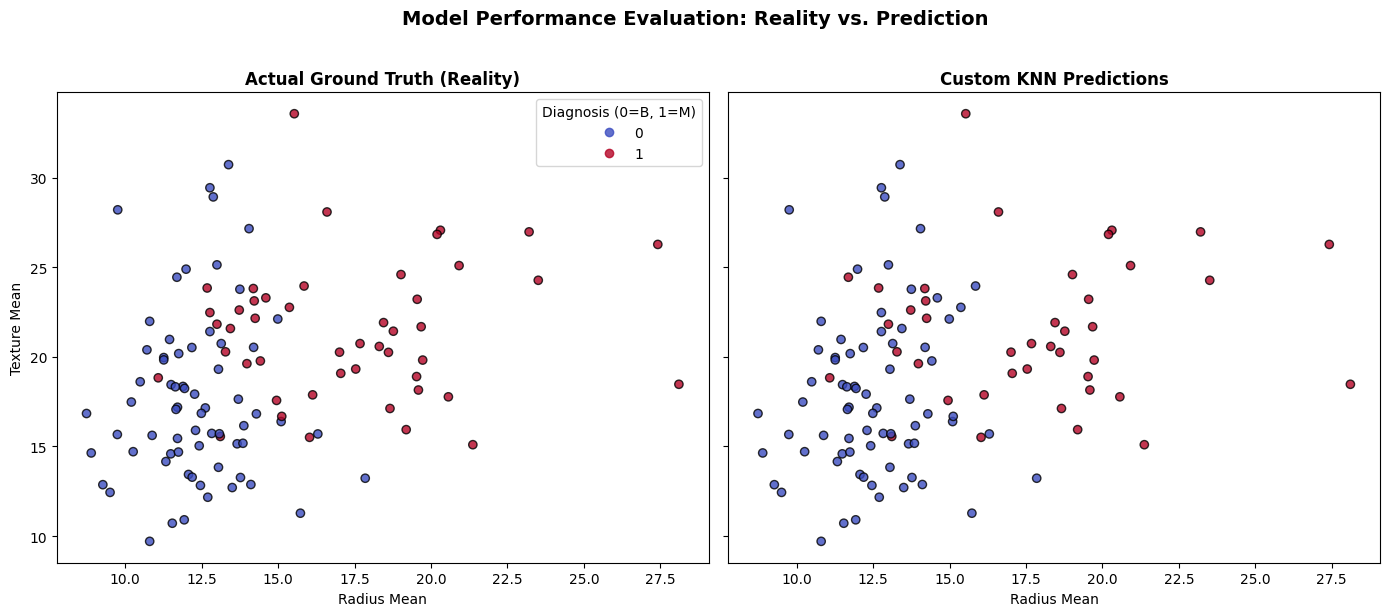

In [19]:
#Visualization
import matplotlib.pyplot as plt

radius_test = X_test[:, 0]
texture_test = X_test[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

#Plot 1: Actual Grounf Truth Labels
scatter1 = ax1.scatter(radius_test, texture_test, c=y_test, cmap='coolwarm', alpha=0.8, edgecolors='k')
ax1.set_title('Actual Ground Truth (Reality)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Radius Mean')
ax1.set_ylabel('Texture Mean')
ax1.legend(*scatter1.legend_elements(), title="Diagnosis (0=B, 1=M)")

#Plot 2: KNN Model's Predictions
scatter2 = ax2.scatter(radius_test, texture_test, c=y_pred, cmap='coolwarm', alpha=0.8, edgecolors='k')
ax2.set_title('Custom KNN Predictions', fontsize=12, fontweight='bold')
ax2.set_xlabel('Radius Mean')

plt.suptitle('Model Performance Evaluation: Reality vs. Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


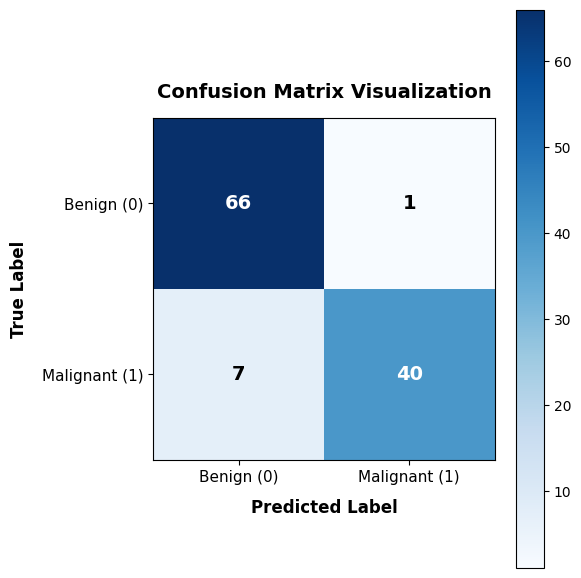

In [20]:
#Visual for the confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))

cax = ax.imshow(confusion_matrix, cmap='Blues', interpolation='nearest')
fig.colorbar(cax)

classes = ['Benign (0)', 'Malignant (1)']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes, fontsize=11)
ax.set_yticklabels(classes, fontsize=11)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('True Label', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Confusion Matrix Visualization', fontsize=14, fontweight='bold', pad=15)

for i in range(2):
    for j in range(2):
        count = confusion_matrix[i, j]
        text_color = "white" if count > (confusion_matrix.max() / 2) else "black"
        ax.text(j, i, f"{count}", ha="center", va="center", color=text_color, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()